### **Preprocesado ✓**

El **objetivo** de esta sección será crear una copia de `X_train` procesada para tratar las distribuciones sesgadas de algunas variables que vimos en el apartado 2 y con un procesado de los outliers. De esta manera se podrá utilizar cuando establezcamos baselines de modelos lineales. También crearemos una copia de `y_test` sin las variables que hemos descartado del dataset original por su correlación con otras features.

Para ello, elegimos `PowerTransformer` dentro de la librería de `sklern.preprocessing`, pues busca estabilizar la varianza y hacer que los datos se parezcan lo máximo posible a una ditribución normal, transformado de manera específica cada una de las columnas (features) según su distribución.

Se elige además el método de Yeo-Johnson porque admite valores negativos, ceros y positivos (presentes en los datos en features como `lon`, `lat` o `dewpoint_mean`).

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
import sys
import os

sys.path.append(os.path.abspath(".."))
from utils.data_utils import guardar_dataset, plot_distribuciones, plot_distribuciones_por_clase, plot_correlacion, plot_boxplots

In [2]:
# Importamos la librería elegida
from sklearn.preprocessing import PowerTransformer

In [3]:
X_train_scaled = pd.read_csv("../data_sample/train_filtered.csv")
X_train = pd.read_csv("../data_sample/train_raw.csv")
X_test = pd.read_csv("../data_sample/test_raw.csv")
X_train_filtered = X_train.drop(columns=["humidity_min", "evapotranspiration_total", "frp"])
y_train = pd.read_csv("../data_sample/y_train.csv")
y_test = pd.read_csv("../data_sample/y_test.csv")

# Se crea una variable para que la columna categórica 'daynight_N'no entre en la transformación y otra con las columnas continuas
col_categorica = "daynight_N"
columnas_continuas = [c for c in X_train_scaled.columns if c != col_categorica]

# Se aplica la transformación de los datos mediant PowerTransformer
spt = PowerTransformer(method="yeo-johnson", standardize=True) 

X_train_scaled[columnas_continuas] = spt.fit_transform(X_train_scaled[columnas_continuas])

Comprobamos que existen cambios en X_train_scaled y que la dispersión de los datos se ha reducido.

In [4]:
X_train_scaled.head()

,daynight_N,lat,lon,fire_weather_index,pressure_mean,wind_direction_mean,wind_direction_std,solar_radiation_mean,dewpoint_mean,cloud_cover_mean,temp_mean,temp_range,wind_speed_max
0,0.0,0.500266,0.042436,2.362052,0.193286,-0.234382,1.023322,0.464192,-0.857211,1.052178,2.039546,1.146858,1.256964
1,0.0,-1.068777,1.522983,1.409680,1.112208,-0.327212,-1.252616,-0.998029,-0.964133,0.014699,-0.306474,-0.823941,1.731070
2,1.0,-0.581959,0.172791,-0.331431,0.334480,-0.450192,0.309297,-0.007010,0.570590,0.072837,0.353678,-0.168571,0.485172
3,0.0,1.359277,-1.419045,-1.175020,0.841019,-0.765510,-0.947565,0.778103,-0.820690,0.875908,-1.990093,0.786644,-0.475380
4,0.0,0.532232,-1.239781,-1.146890,1.250837,0.188794,0.502953,0.312456,1.997179,1.418256,0.768440,-1.296800,-1.339320


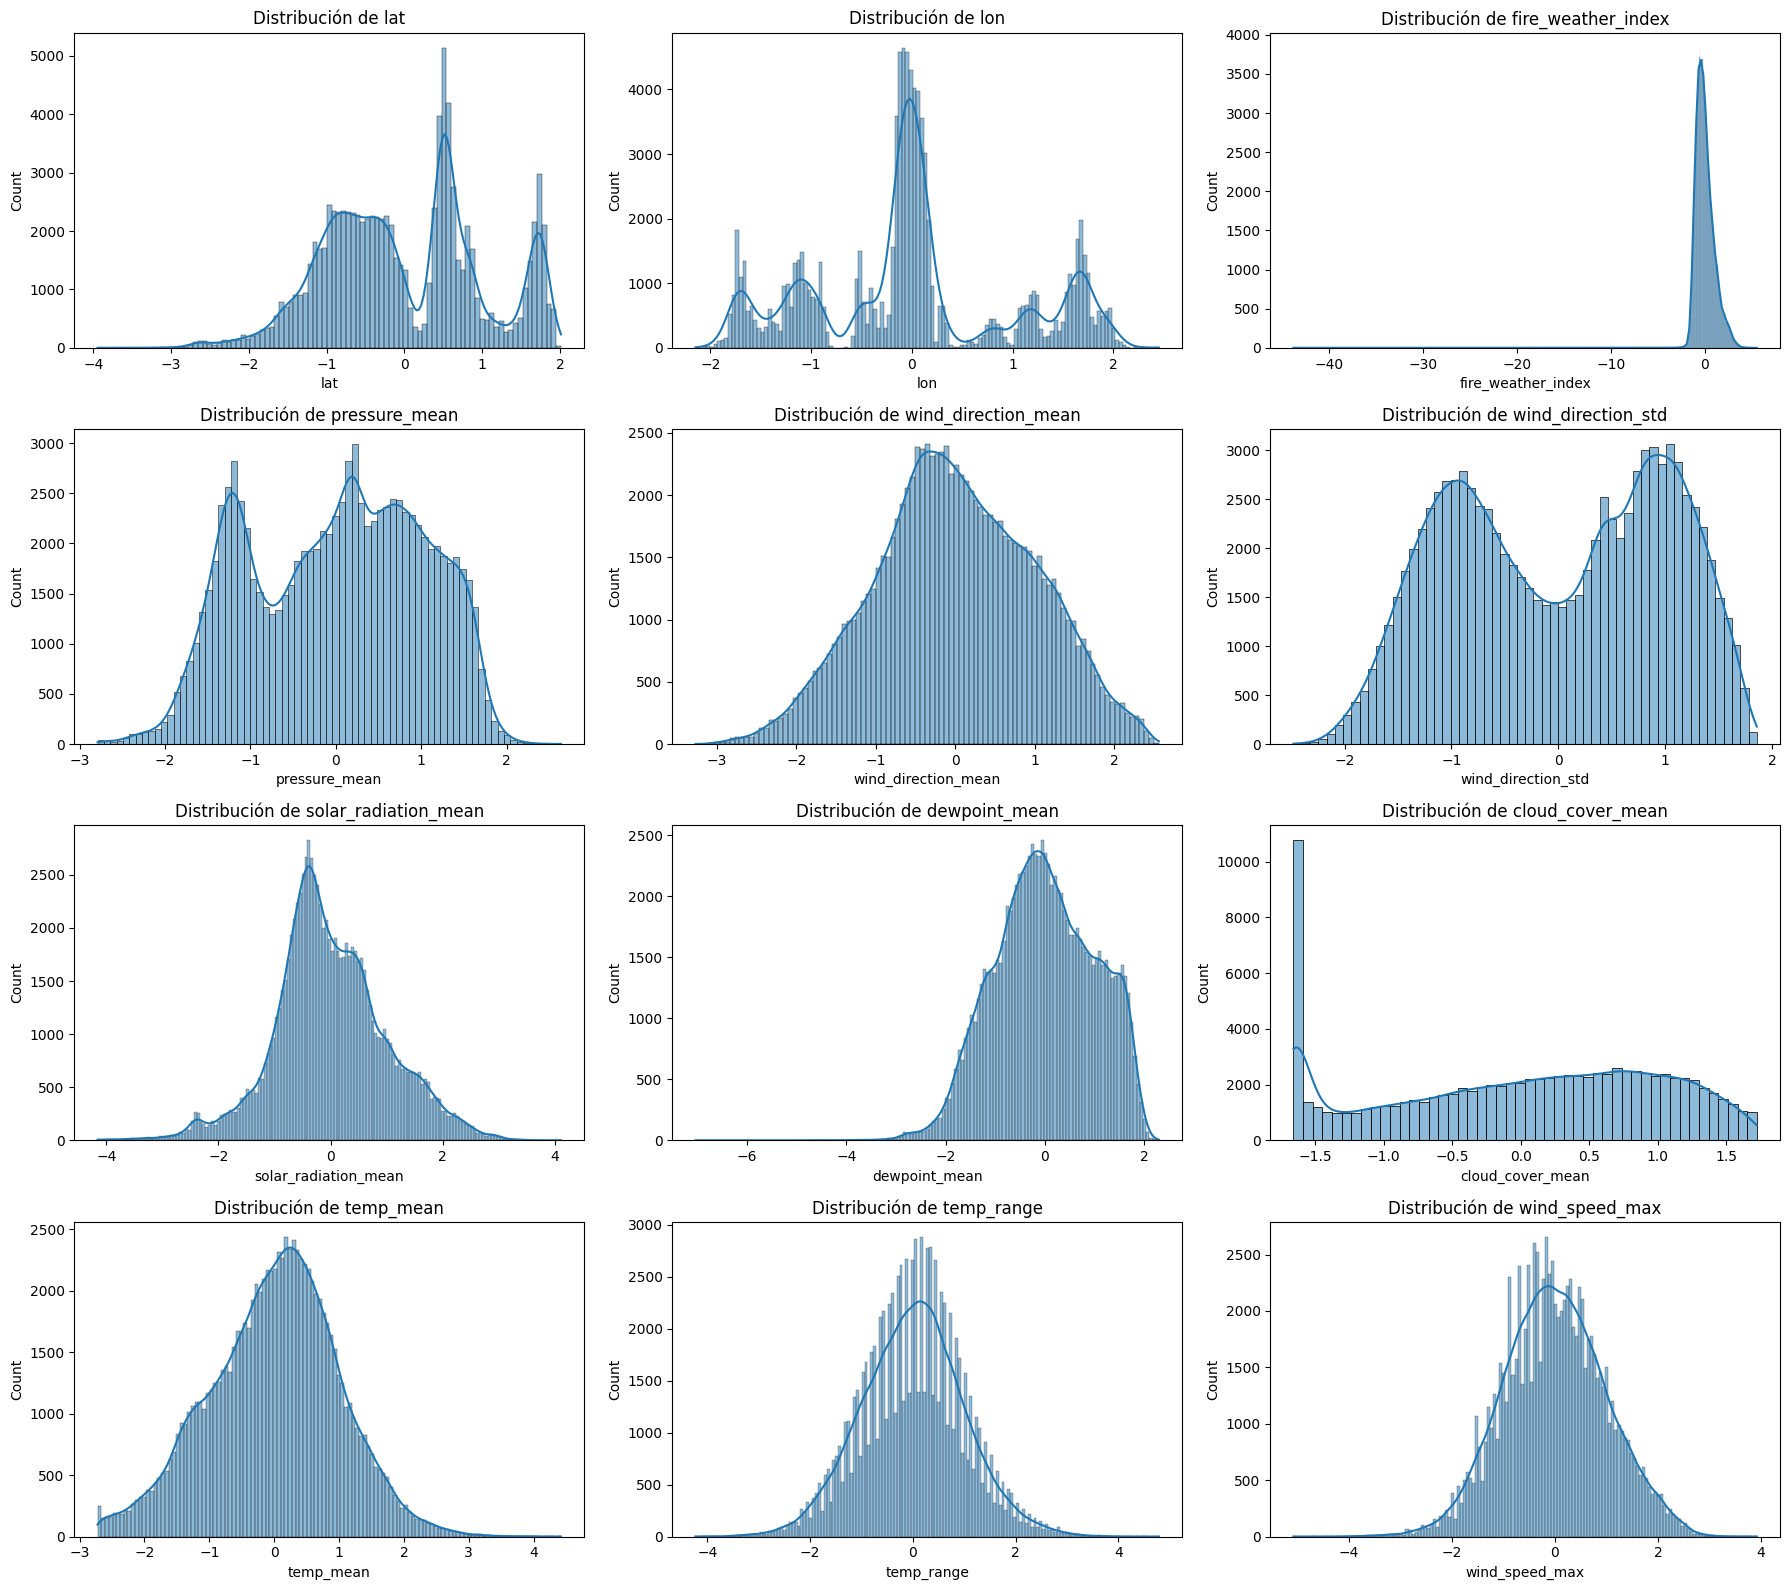

In [5]:
plot_distribuciones(X_train_scaled.drop(columns="daynight_N"))

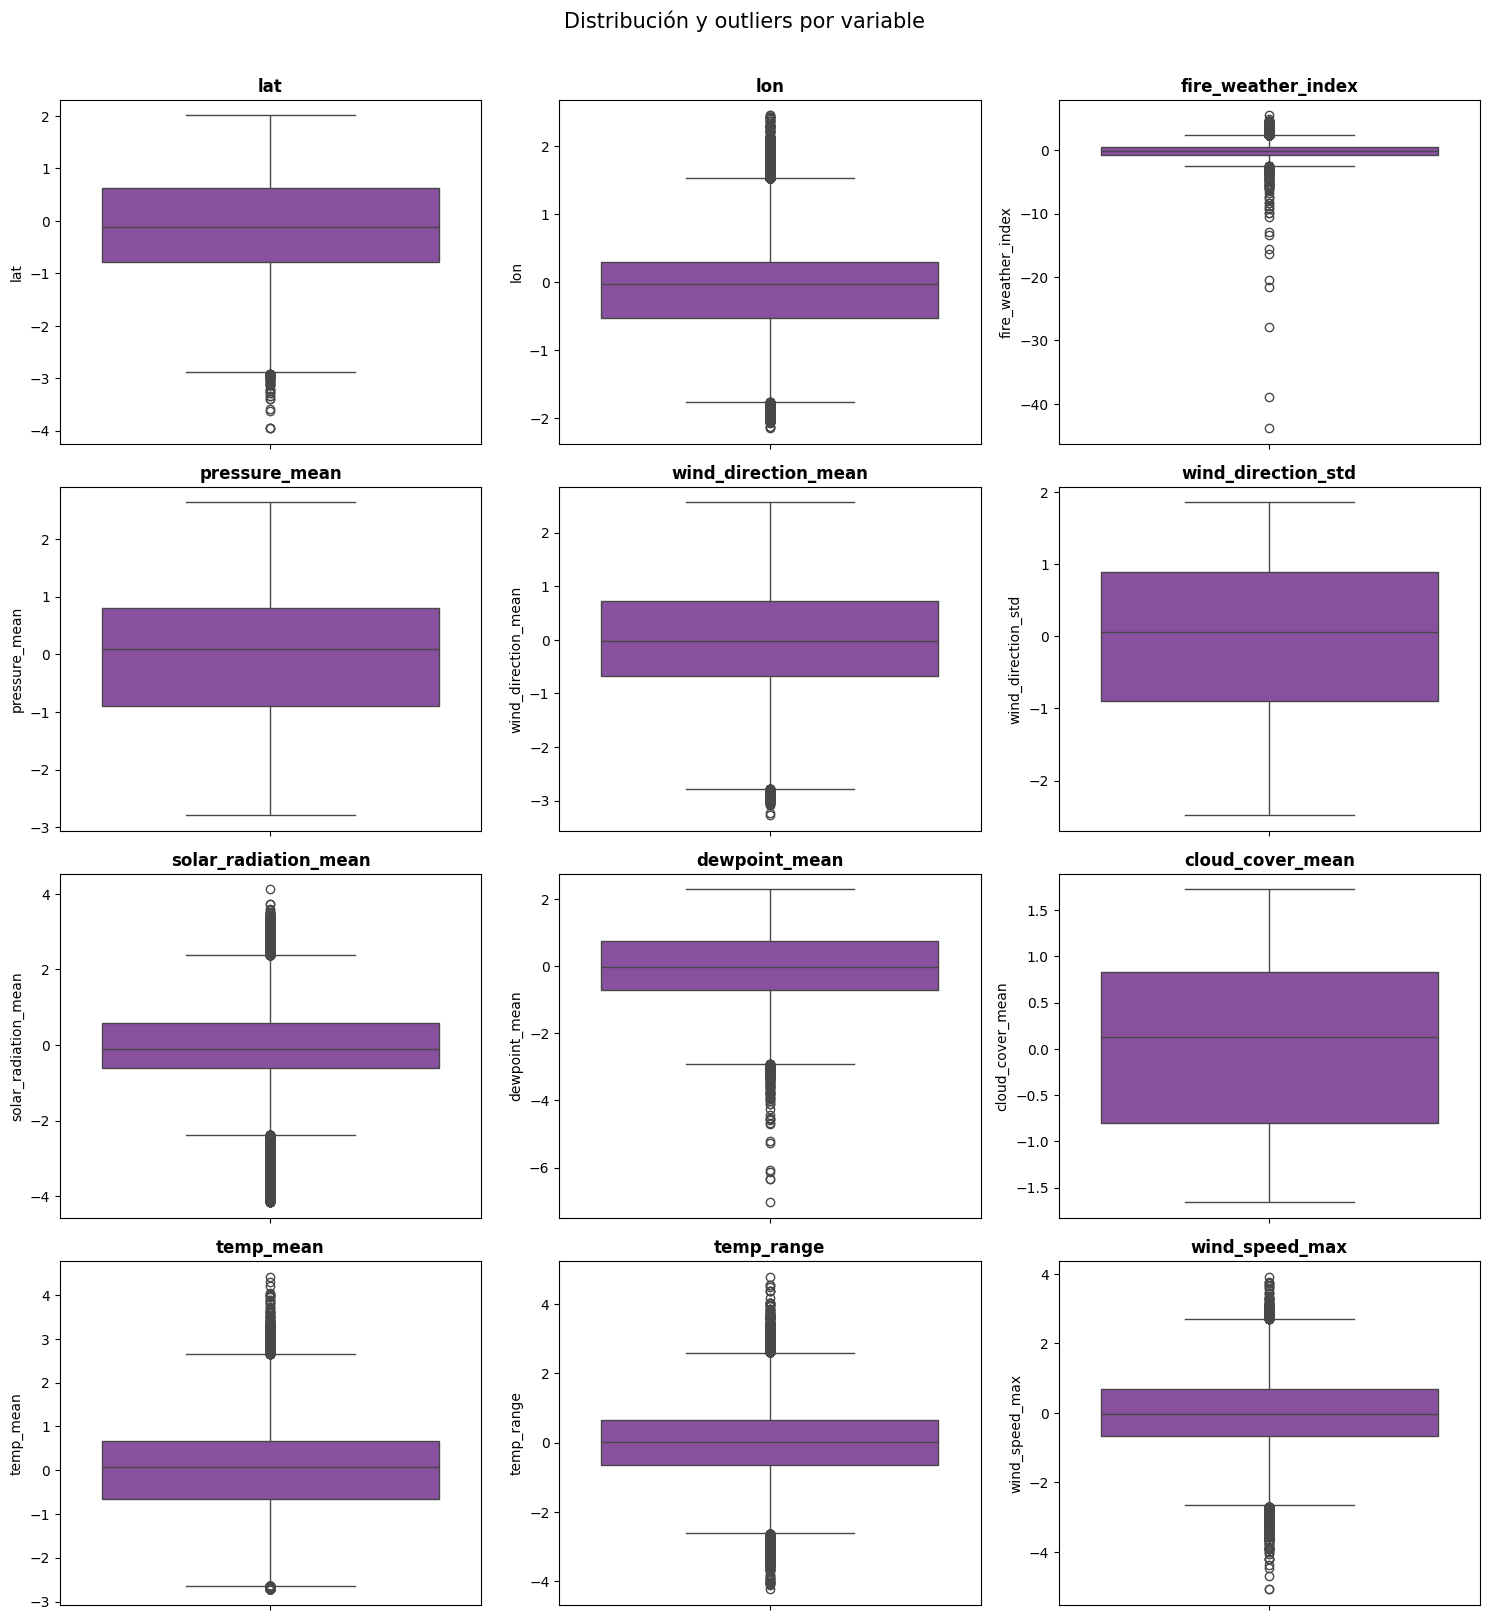

In [6]:
plot_boxplots(X_train_scaled.drop(columns="daynight_N"), color="#8D44AC")

Para comprobar que en efecto el tratamiento de outliers ha sido efectivo, vamos a calcular el **coeficiente de asimetría (skewness)**,  que busca cuantificar cuánto se desvía la distribución de una variable respecto a una forma simétrica De esta forma:

- **Skew ≈ 0** → distribución aproximadamente simétrica (similar a una normal)
- **Skew > 0** → cola larga hacia la derecha (valores atípicos altos "estiran" la distribución)
- **Skew < 0** → cola larga hacia la izquierda (valores atípicos bajos "estiran" la distribución)
- **|Skew| > |2|** → distribución muy asimétrica, con presencia de valores extremos que se alejan mucho del grueso de los datos

In [7]:
# Aplicamos el método .skew() de pandas
for col in X_train_scaled.columns:
    skew_antes = X_train_filtered[col].skew()
    skew_despues = X_train_scaled[col].skew()
    print(f"{col}: Antes={skew_antes:.2f} | Después={skew_despues:.2f}")

daynight_N: Antes=1.96 | Después=1.96
lat: Antes=1.03 | Después=0.07
lon: Antes=-0.15 | Después=0.21
fire_weather_index: Antes=2.57 | Después=-1.39
pressure_mean: Antes=-0.93 | Después=-0.14
wind_direction_mean: Antes=0.47 | Después=-0.03
wind_direction_std: Antes=0.54 | Después=-0.09
solar_radiation_mean: Antes=-0.36 | Después=0.06
dewpoint_mean: Antes=-0.24 | Después=-0.14
cloud_cover_mean: Antes=0.55 | Después=-0.25
temp_mean: Antes=-1.19 | Después=-0.12
temp_range: Antes=-0.09 | Después=0.02
wind_speed_max: Antes=1.09 | Después=0.00


Vemos que todos los valores obtenidos tras la normalización se encuentran cerca de cero, por lo que consideramos que la transformación de los datos ha sido efectiva. Procedemos a guardar esta versión escalada de los datos, junto con la versión con el filtrado de variables. También creamos un archivo sin las features seleccionadas para X_test.

In [8]:
X_test_filtered = X_test.drop(columns=["humidity_min", "evapotranspiration_total", "frp"])

In [9]:
guardar_dataset(X_train_scaled, "train_scaled")
guardar_dataset(X_train_filtered, "train_filtered")
guardar_dataset(X_test_filtered, "test_filtered")
guardar_dataset(y_train, "y_train")
guardar_dataset(y_test, "y_test")

Dataset guardado en: src/data_sample\train_scaled.csv (95086 filas, 13 columnas)
Dataset guardado en: src/data_sample\train_filtered.csv (95086 filas, 13 columnas)
Dataset guardado en: src/data_sample\test_filtered.csv (23772 filas, 13 columnas)
Dataset guardado en: src/data_sample\y_train.csv (95086 filas, 1 columnas)
Dataset guardado en: src/data_sample\y_test.csv (23772 filas, 1 columnas)


'src/data_sample\\y_test.csv'